Mounted at /content/drive
Files ready on the local disk

 Start Training CNN From Scratch...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 95ms/step - accuracy: 0.7471 - auc: 0.8233 - loss: 0.7464 - val_accuracy: 0.6681 - val_auc: 0.6742 - val_loss: 0.9978 - learning_rate: 1.0000e-04
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7827 - auc: 0.8609 - loss: 0.6816 - val_accuracy: 0.7621 - val_auc: 0.8760 - val_loss: 0.7391 - learning_rate: 1.0000e-04
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7972 - auc: 0.8744 - loss: 0.6479 - val_accuracy: 0.8125 - val_auc: 0.8979 - val_loss: 0.6151 - learning_rate: 1.0000e-04
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8061 - auc: 0.8837 - loss: 0.6207 - val_accuracy: 0.8188 - val_auc: 0.9086 - val_loss: 0.5707 - learning_rate: 1.0000e-04
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8113 - auc: 0.8907 - loss: 0.5976 - val_accuracy: 0.8175 - val_auc: 0.9023 - va

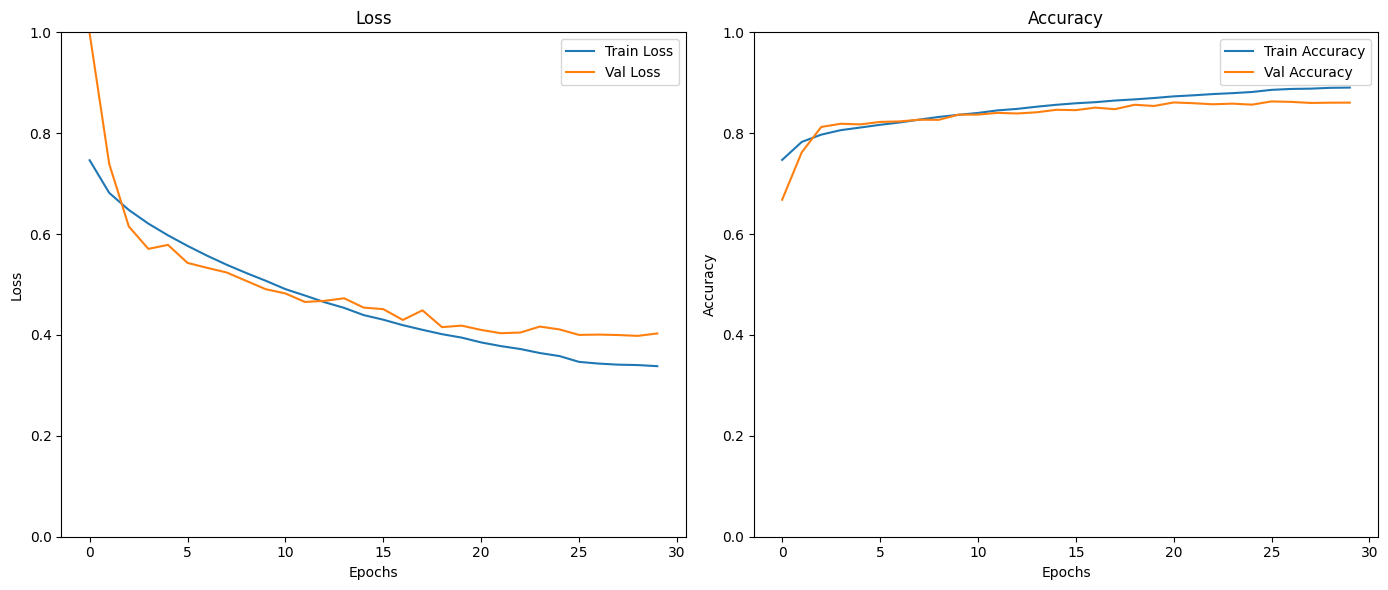


 Final evaluation on test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
              precision    recall  f1-score   support

     Healthy       0.80      0.85      0.83     16391
       Tumor       0.84      0.79      0.81     16377

    accuracy                           0.82     32768
   macro avg       0.82      0.82      0.82     32768
weighted avg       0.82      0.82      0.82     32768



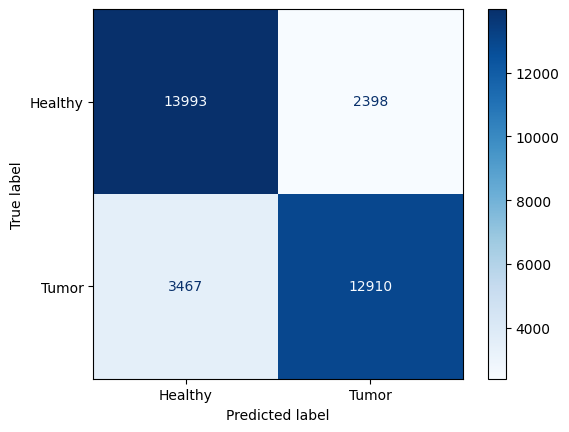

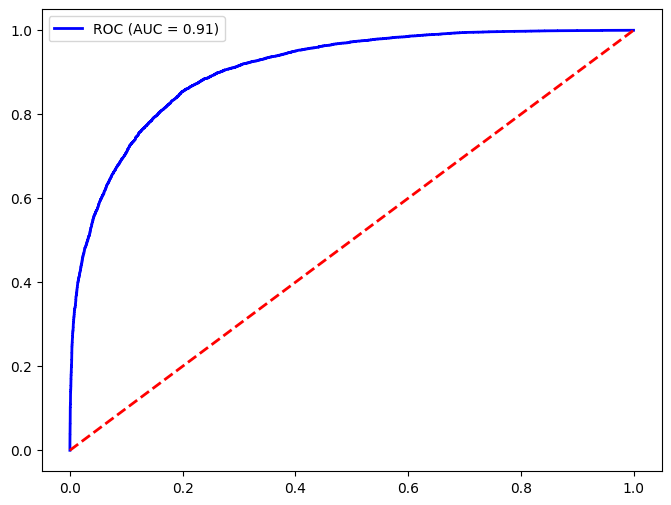

In [ ]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- FILE PREPARATION ---
!rm -rf /content/*.h5
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src):
        !cp "$src" /content/
print("Files ready on the local disk")

np.random.seed(42)
tf.random.set_seed(42)

# --- LOADING DATA ---
def load_to_ram(x_path, y_path, num_samples=80000):
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:num_samples].reshape(-1, 1).astype('float32')
    with h5py.File(x_path, 'r') as fx:
        x_all = fx['x'][:num_samples]
    return x_all, y_all

X_train, Y_train = load_to_ram('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)
X_val, Y_val = load_to_ram('/content/camelyonpatch_level_2_split_valid_x.h5',
                                    '/content/camelyonpatch_level_2_split_valid_y.h5', 8000)

# --- DATA AUGMENTATION ---
def augment(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 80, 80)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    return image, label

def process_val(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 80, 80)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# --- CNN FROM SCRATCH ARCHITECTURE---
tf.keras.mixed_precision.set_global_policy('mixed_float16')
l2_val = 5e-4 # Portato a 5e-4 come nella ResNet

def build_cnn_from_scratch():
    inputs = layers.Input(shape=(80, 80, 3))

    # First Layer
    x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # Second Layer
    x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # Third Layer
    x = layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # Fourth Layer 
    x = layers.Conv2D(256, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)

    # Classifier Head 
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    return models.Model(inputs, outputs)

model = build_cnn_from_scratch()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
              jit_compile=True)

# --- TRAINING PHASE ---
BATCH_SIZE = 256

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train))\
    .shuffle(10000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val))\
    .map(process_val, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"\n Start Training CNN From Scratch...")
history = model.fit(train_ds, validation_data=val_ds, epochs=30,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True),
                               callbacks.ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)])

# Model saving
model.save('/content/drive/MyDrive/CNN_from_scratch_allineata.keras')

# PLOT OF FIGURES
plt.figure(figsize=(14,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.ylim(0, 1.0); plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy"); plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.ylim(0, 1.0); plt.legend()

plt.tight_layout()
plt.show()

# --- FINAL EVALUATION ---
print("\n Final evaluation on test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1).astype('float32')

test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test))\
    .map(process_val).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.35).astype(int)

print(classification_report(Y_test, y_pred, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues', values_format='d'); plt.show()

fpr, tpr, _ = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6)); plt.plot(fpr, tpr, color="blue", lw=2, label="ROC (AUC = %0.2f)" % roc_auc); plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--"); plt.legend(); plt.show()